In [8]:
%load_ext autoreload
%autoreload 2

import os
import sys
module_path = os.path.abspath(os.path.join('../..'))
if module_path not in sys.path:
    sys.path.append(module_path)

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import pandas as pd
import jax

jax.config.update('jax_platforms', 'cpu')

plt.rcParams['font.family'] = 'Helvetica Light'

from behavioral_plotting import (
    plot_session,
    load_odor_site_df,
    plot_patch_statistics_by_session,
    plot_patch_statistics,
    plot_multi_df_accuracy_heatmap,
    plot_leave_probabilities,
    plot_rewards_vs_interpatch_distance,
    append_index_phase,
    plot_grouped_mean_std,
    plot_stop_fraction,
    odor_colors,
)
from aux_funcs import format_plot
from nb_analysis_tools import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
# had to clear the font cache to get the Helvetica Light font to work.
# If you see a warning about missing fonts, run this cell and restart the kernel.

# import matplotlib as mpl
# import shutil, os

# # Find and delete the font cache
# cache_dir = mpl.get_cachedir()
# print(f"Cache dir: {cache_dir}")

# # Delete cache files
# for f in os.listdir(cache_dir):
#     if f.endswith('.json') or f.endswith('.cache'):
#         os.remove(os.path.join(cache_dir, f))
#         print(f"Deleted: {f}")

# print("Done — restart the kernel now")

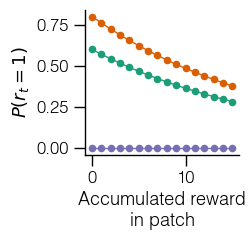

In [3]:
# ── Exponential decay curves ──────────────────────────────────────────────
prefactors  = [0,  0.6,  0.8]   # one per curve
decay_rates = [1,  1/20,  1/20]   # one per curve

x = np.arange(16)   # 0 through 20

fig, ax = plt.subplots(figsize=(2.5, 2.5))
for prefactor, decay_rate, color in zip(prefactors, decay_rates, odor_colors):
    y = prefactor * np.exp(-decay_rate * x)
    ax.plot(x, y, color=color, lw=1)
    ax.scatter(x, y, color=color, s=20)
ax.set_xlabel('Accumulated reward\nin patch')
ax.set_ylabel(r'$P(r_t=1)$')
format_plot(ax)
plt.tight_layout()
plt.show()

In [4]:
FIXED_EXP_GRU_INITIAL_PROB_OFFSET_NETWORKS = [
    '../../../results/fixed_exp_gru_initial_prob_offset_v4_net0/trajectories_20260529_141949.pkl',
    '../../../results/fixed_exp_gru_initial_prob_offset_v4_net1/trajectories_20260529_145421.pkl',
    '../../../results/fixed_exp_gru_initial_prob_offset_v4_net2/trajectories_20260529_152843.pkl',
    '../../../results/fixed_exp_gru_initial_prob_offset_v4_net3/trajectories_20260529_160251.pkl',
    '../../../results/fixed_exp_gru_initial_prob_offset_v4_net4/trajectories_20260529_163734.pkl',
]

FIXED_EXP_GRU_INITIAL_PROB_OFFSET_NETWORKS_WITH_INTERVENTION = [
    '../../../results/fixed_exp_gru_initial_prob_offset_v4_intersite_intervention/trajectories_20260602_142751.pkl',
    '../../../results/fixed_exp_gru_initial_prob_offset_v4_intersite_intervention/trajectories_20260602_142919.pkl',
    '../../../results/fixed_exp_gru_initial_prob_offset_v4_intersite_intervention/trajectories_20260602_143048.pkl',
    '../../../results/fixed_exp_gru_initial_prob_offset_v4_intersite_intervention/trajectories_20260602_143215.pkl',
    '../../../results/fixed_exp_gru_initial_prob_offset_v4_intersite_intervention/trajectories_20260602_143340.pkl',
]


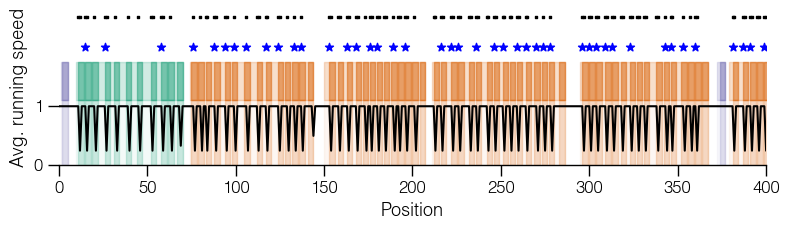

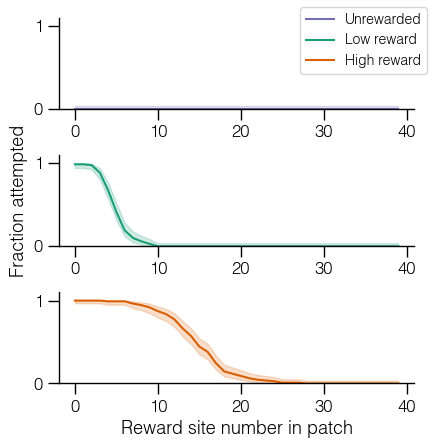

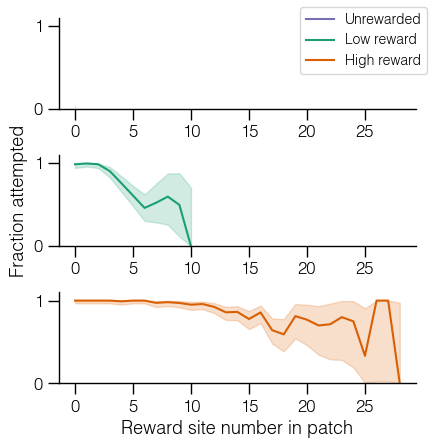

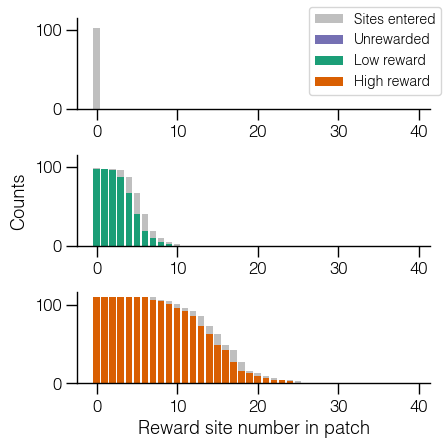

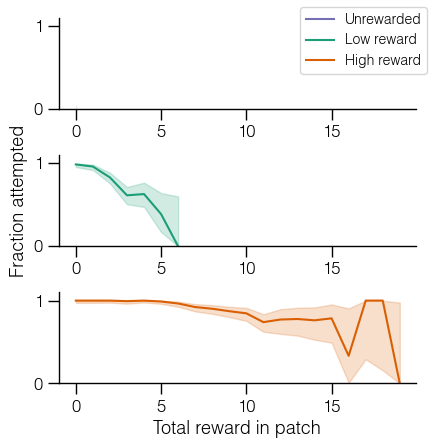

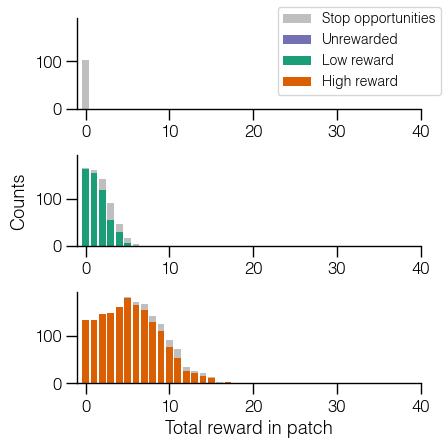

In [22]:
for i, data_path in enumerate(FIXED_EXP_GRU_INITIAL_PROB_OFFSET_NETWORKS):
    plot_session(data_path, session_idx=0, xlim=(0, 400), max_reward_param=40, max_reward_sites=30, use_fixed_colors=True, save_dir=f'../../../figures/gru_fixed_exp_offset_net_{i}')

In [6]:
dfs = [
    load_odor_site_df(x, nn_num=nn_num, brief=False)
    for nn_num, x in enumerate(FIXED_EXP_GRU_INITIAL_PROB_OFFSET_NETWORKS)
]

Session data loaded
Session summaries generated
Session data loaded
Session summaries generated
Session data loaded
Session summaries generated
Session data loaded
Session summaries generated
Session data loaded
Session summaries generated


In [65]:
dfs_with_intervention = [
    load_odor_site_df(x, nn_num=nn_num, brief=True)
    for nn_num, x in enumerate(FIXED_EXP_GRU_INITIAL_PROB_OFFSET_NETWORKS_WITH_INTERVENTION)
]

Session data loaded
Session summaries generated
Session data loaded
Session summaries generated
Session data loaded
Session summaries generated
Session data loaded
Session summaries generated
Session data loaded
Session summaries generated


<string>:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

<string>:61: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



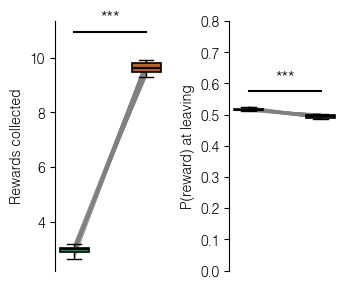

<string>:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

<string>:61: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



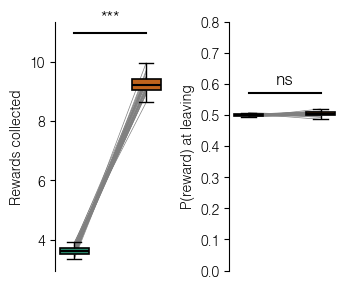

<string>:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

<string>:61: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



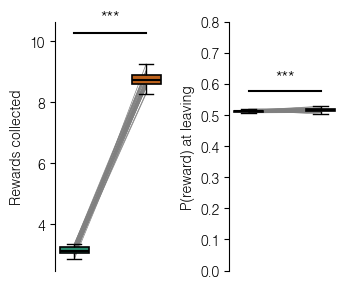

<string>:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

<string>:61: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



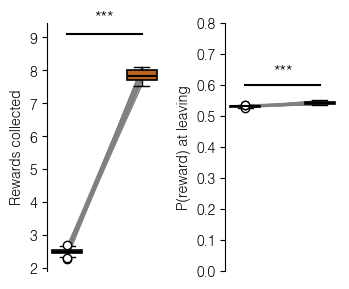

<string>:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

<string>:61: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



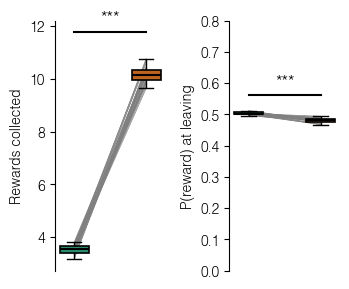

In [46]:
for df in dfs:
    plot_patch_statistics_by_session(
        df,
        x_axis='patch_type',
        offsets=[0, 0.6, 0.8],
        x_mask=[0, 1, 1],
        fixed_colors=True,
        x_tick_labels=['Low', 'High'],
        ylim_right=[0, 0.8],
    )

In [ ]:
# fig = plot_patch_statistics(pd.concat(dfs))
# savefig(fig, '../../figures/offset_networks_mvp_plots')

Processing GRU (offset)...
Processing GRU (offset)...
Processing GRU (offset)...
Processing GRU (offset)...
Processing GRU (offset)...


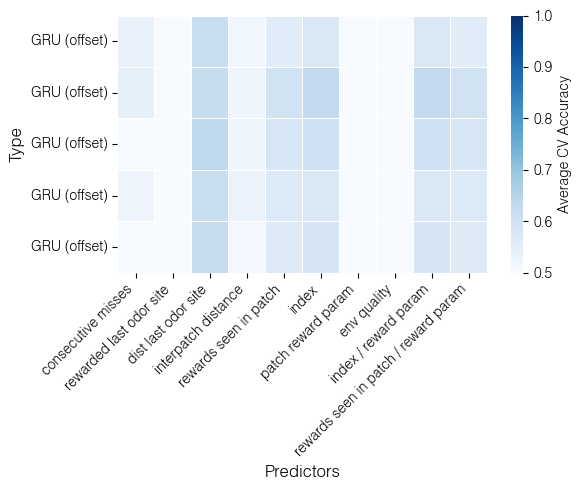

In [7]:
plot_multi_df_accuracy_heatmap(
    [df[(df['index'] > 0) & (~np.isnan(df['interpatch_distance']))] for df in dfs],
    [
        'consecutive_misses',
        'rewarded_last_odor_site',
        'dist_last_odor_site',
        'interpatch_distance',
        'rewards_seen_in_patch',
        'index',
        'patch_reward_param',
        'env_quality',
        'index / reward_param',
        'rewards_seen_in_patch / reward_param',
    ],
    df_labels=['GRU (offset)'] * len(dfs),
    figsize=(6, 5),
)

In [95]:
dfs[0]['interpatch_distance']

0    NaN
0    5.0
0    5.0
0    5.0
0    5.0
    ... 
0    1.0
0    1.0
0    1.0
0    1.0
0    1.0
Name: interpatch_distance, Length: 75036, dtype: float64

/home/david.bell/work/favorably_connected_2/code/behavioral_plotting.py:480: UserWarning: The figure layout has changed to tight
  


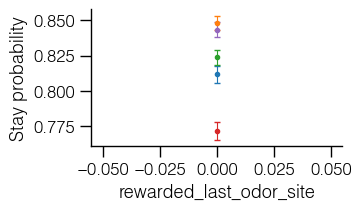

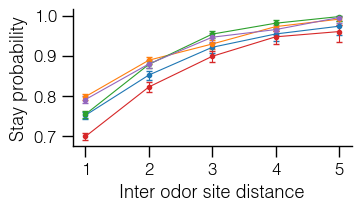

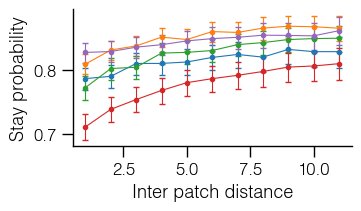

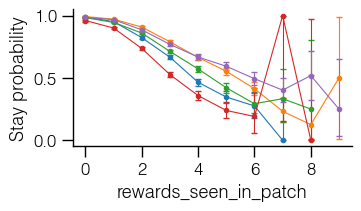

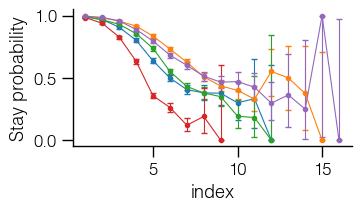

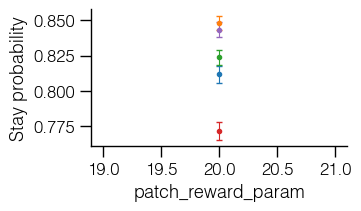

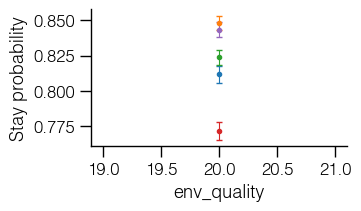

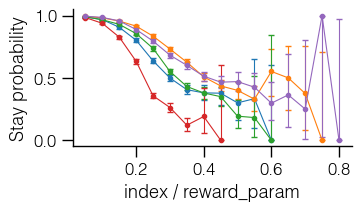

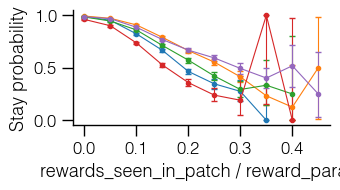

In [96]:
plot_leave_probabilities(
    [df[(df['index'] > 0) & (df['patch_type'] == 1) & (~np.isnan(df['interpatch_distance']))] for df in dfs],
    [
        'rewarded_last_odor_site',
        'dist_last_odor_site',
        'interpatch_distance',
        'rewards_seen_in_patch',
        'index',
        'patch_reward_param',
        'env_quality',
        'index / reward_param',
        'rewards_seen_in_patch / reward_param',
    ],
    x_labels=[
        'rewarded_last_odor_site',
        'Inter odor site distance',
        'Inter patch distance',
        'rewards_seen_in_patch',
        'index',
        'patch_reward_param',
        'env_quality',
        'index / reward_param',
        'rewards_seen_in_patch / reward_param',
    ],
)

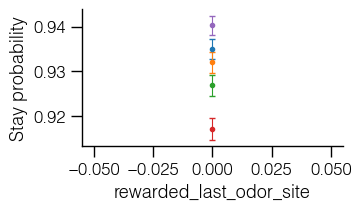

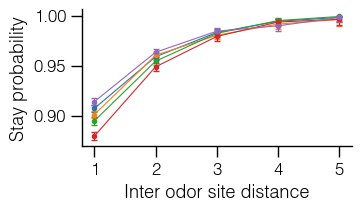

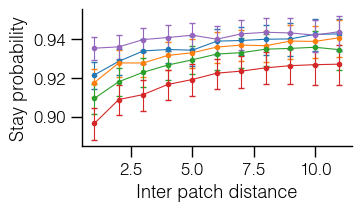

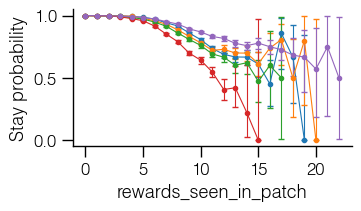

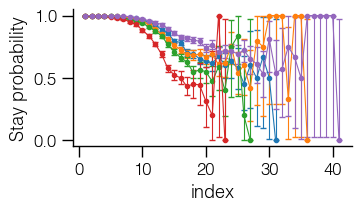

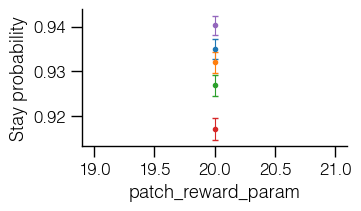

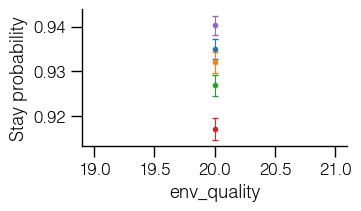

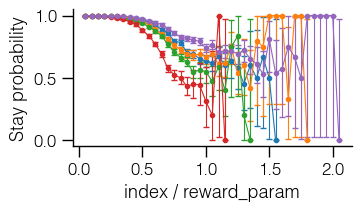

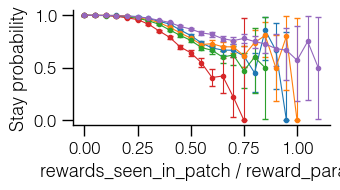

In [98]:
plot_leave_probabilities(
    [df[(df['index'] > 0) & (df['patch_type'] == 2) & (~np.isnan(df['interpatch_distance']))] for df in dfs],
    [
        'rewarded_last_odor_site',
        'dist_last_odor_site',
        'interpatch_distance',
        'rewards_seen_in_patch',
        'index',
        'patch_reward_param',
        'env_quality',
        'index / reward_param',
        'rewards_seen_in_patch / reward_param',
    ],
    x_labels=[
        'rewarded_last_odor_site',
        'Inter odor site distance',
        'Inter patch distance',
        'rewards_seen_in_patch',
        'index',
        'patch_reward_param',
        'env_quality',
        'index / reward_param',
        'rewards_seen_in_patch / reward_param',
    ],
)

/home/david.bell/work/favorably_connected_2/code/behavioral_plotting.py:480: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


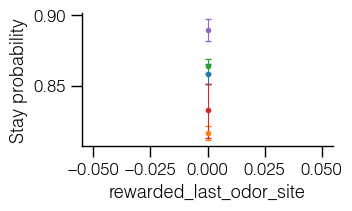

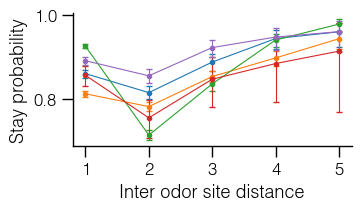

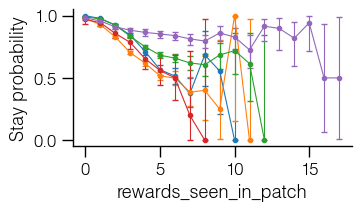

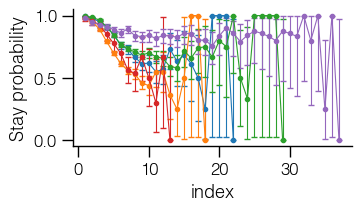

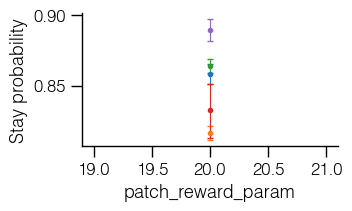

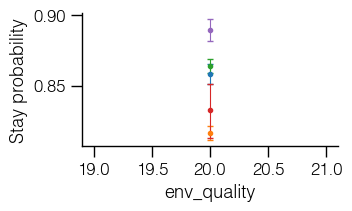

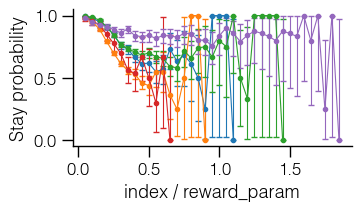

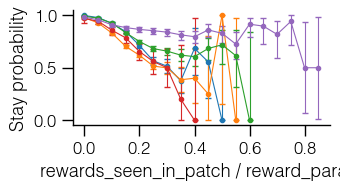

In [67]:
plot_leave_probabilities(
    [df[(df['index'] > 0) & (df['patch_type'] == 1)] for df in dfs_with_intervention],
    [
        'rewarded_last_odor_site',
        'dist_last_odor_site',
        'rewards_seen_in_patch',
        'index',
        'patch_reward_param',
        'env_quality',
        'index / reward_param',
        'rewards_seen_in_patch / reward_param',
    ],
    x_labels=[
        'rewarded_last_odor_site',
        'Inter odor site distance',
        'rewards_seen_in_patch',
        'index',
        'patch_reward_param',
        'env_quality',
        'index / reward_param',
        'rewards_seen_in_patch / reward_param',
    ],
)

/home/david.bell/work/favorably_connected_2/code/behavioral_plotting.py:480: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


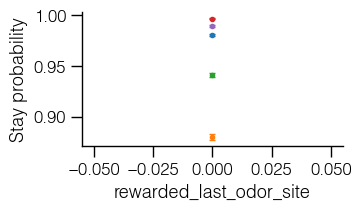

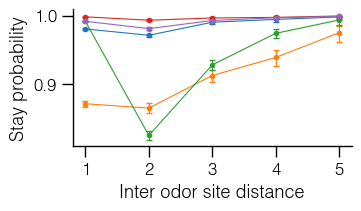

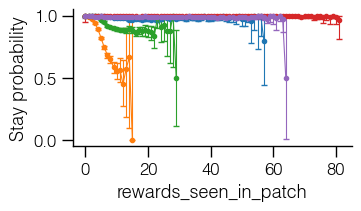

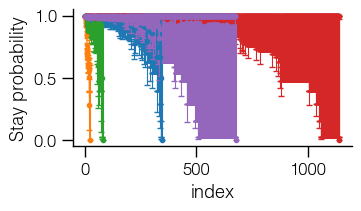

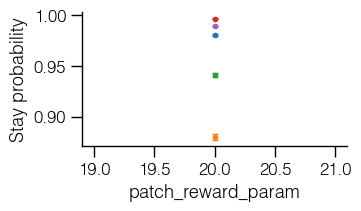

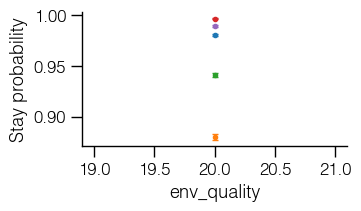

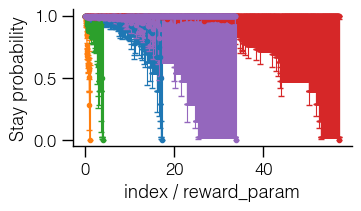

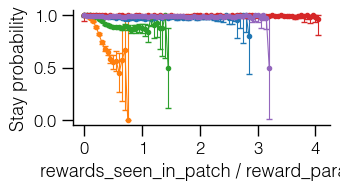

In [70]:
plot_leave_probabilities(
    [df[(df['index'] > 0) & (df['patch_type'] == 2)] for df in dfs_with_intervention],
    [
        'rewarded_last_odor_site',
        'dist_last_odor_site',
        'rewards_seen_in_patch',
        'index',
        'patch_reward_param',
        'env_quality',
        'index / reward_param',
        'rewards_seen_in_patch / reward_param',
    ],
    x_labels=[
        'rewarded_last_odor_site',
        'Inter odor site distance',
        'rewards_seen_in_patch',
        'index',
        'patch_reward_param',
        'env_quality',
        'index / reward_param',
        'rewards_seen_in_patch / reward_param',
    ],
)

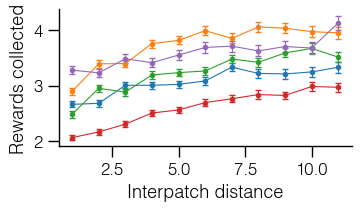

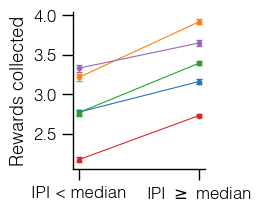

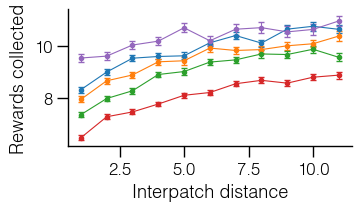

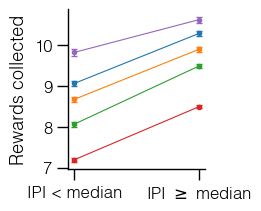

In [115]:

plot_rewards_vs_interpatch_distance(
    [df[(df["index"] > 0) & (~np.isnan(df["interpatch_distance"])) & (df["patch_type"] == 1)] for df in dfs],
)

plot_rewards_vs_interpatch_distance(
    [df[(df["index"] > 0) & (~np.isnan(df["interpatch_distance"])) & (df["patch_type"] == 2)] for df in dfs],
)


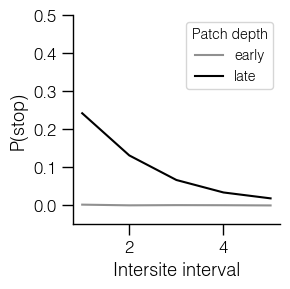

In [29]:
fig = plot_grouped_mean_std(
    append_index_phase(pd.concat([df[df['index'] > 0] for df in dfs])),
    'dist_last_odor_site',
    'segment',
    'stopped',
    'network_num',
)
# savefig(fig, '../../figures/offset_intersite_interval_early_late')

In [101]:
# code goes here
dfs[0].columns

Index(['interpatch_distance', 'dist_last_odor_site', 'patch_reward_param',
       'index', 'stopped', 'rewarded', 'rewarded_last_odor_site', 'added',
       'rewards_seen_in_patch', 'global_reward_rate_param', 'patch_number',
       'session_number', 'patch_type', 'env_quality', 'index / reward_param',
       'rewards_seen_in_patch / reward_param', 'network_num'],
      dtype='object')

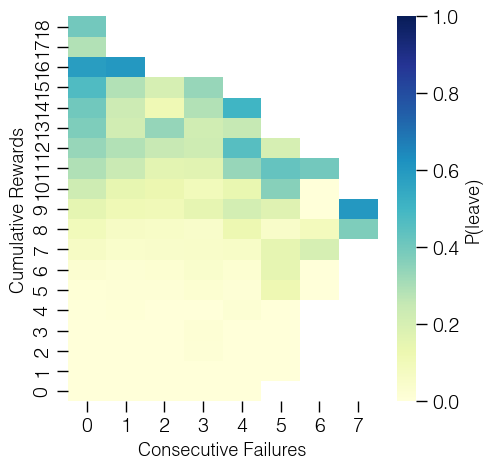

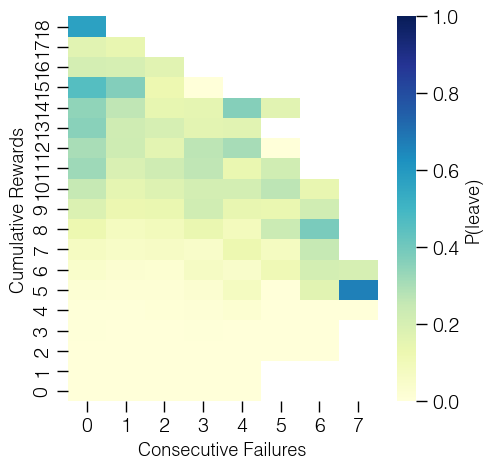

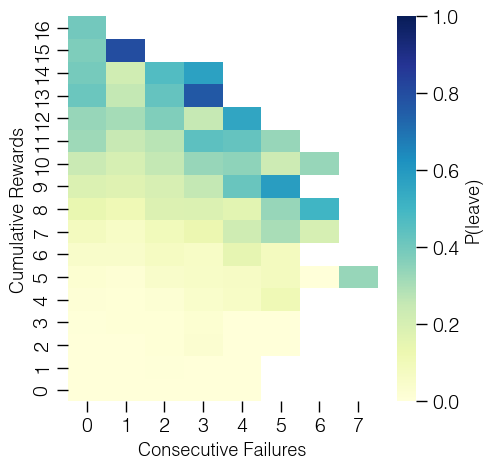

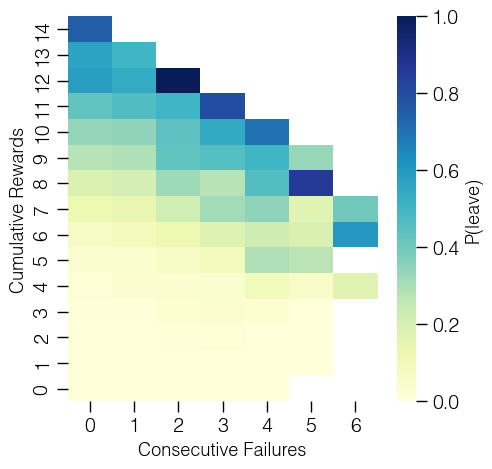

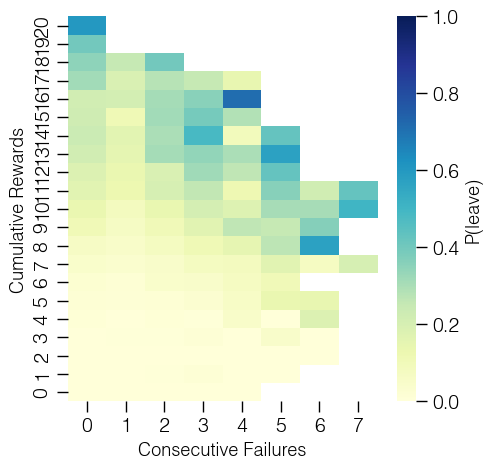

In [50]:
for df in dfs:
    plot_stop_fraction(
        df,
        'consecutive_misses',
        'rewards_seen_in_patch',
        condition=lambda x: x[x['patch_type'] == 2],
        invert_y=True,
        figsize=(5, 5),
        reverse=True,
        xlabel='Consecutive Failures',
        ylabel='Cumulative Rewards',
        min_n=5,
    )
None

In [ ]:
dfs[0].columns

Index(['dist_last_odor_site', 'patch_reward_param', 'index', 'stopped',
       'rewarded', 'rewarded_last_odor_site', 'added', 'rewards_seen_in_patch',
       'global_reward_rate_param', 'patch_number', 'session_number',
       'consecutive_misses', 'rewarded_1', 'rewarded_2', 'rewarded_3',
       'rewarded_4', 'rewarded_5', 'rewarded_6', 'rewarded_7', 'rewarded_8',
       'rewarded_9', 'rewarded_10', 'rewarded_11', 'rewarded_12',
       'rewarded_13', 'rewarded_14', 'rewarded_15', 'rewarded_16',
       'rewarded_17', 'rewarded_18', 'rewarded_19', 'rewarded_20',
       'rewarded_21', 'rewarded_22', 'rewarded_23', 'rewarded_24',
       'rewarded_25', 'rewarded_26', 'rewarded_27', 'rewarded_28',
       'rewarded_29', 'rewarded_30', 'rewarded_31', 'rewarded_32',
       'rewarded_33', 'rewarded_34', 'rewarded_35', 'rewarded_36',
       'rewarded_37', 'rewarded_38', 'rewarded_39', 'rewarded_40',
       'rewarded_41', 'rewarded_42', 'rewarded_43', 'rewarded_44',
       'rewarded_45', 'reward

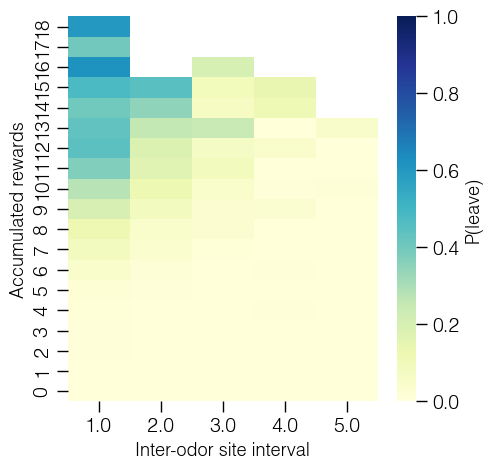

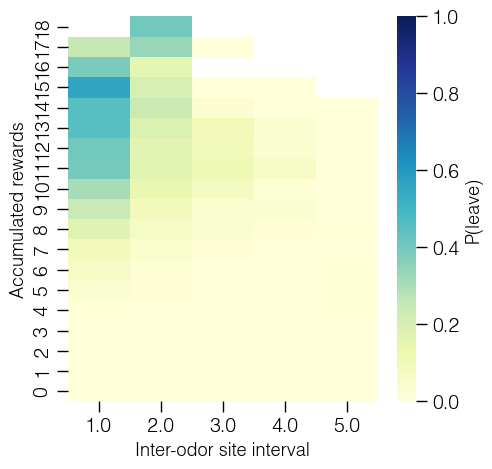

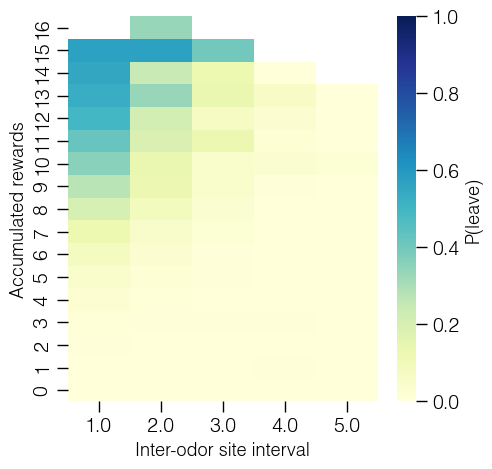

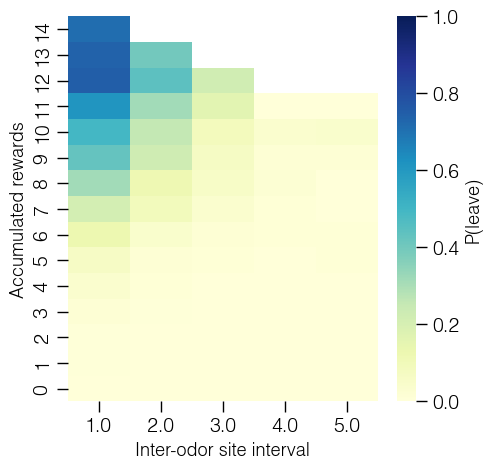

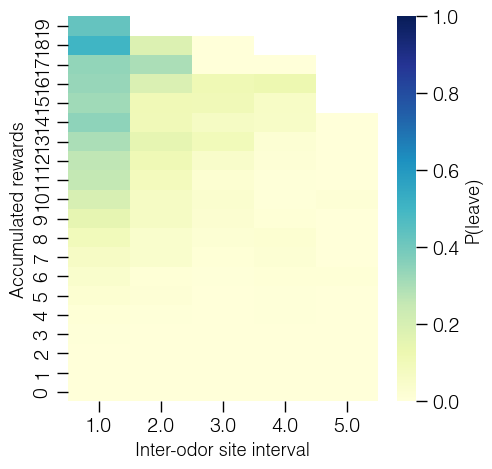

In [48]:
for df in dfs:
    plot_stop_fraction(
        df,
        'dist_last_odor_site',
        'rewards_seen_in_patch',
        condition=lambda x: x[x['patch_type'] == 2],
        invert_y=True,
        figsize=(5, 5),
        reverse=True,
        xlabel='Inter-odor site interval',
        ylabel='Accumulated rewards',
        min_n=5,
    )
None

In [17]:
print(dfs[0].columns)

Index(['dist_last_odor_site', 'patch_reward_param', 'index', 'stopped',
       'rewarded', 'rewarded_last_odor_site', 'added', 'rewards_seen_in_patch',
       'global_reward_rate_param', 'patch_number', 'session_number',
       'patch_type', 'consecutive_misses', 'rewarded_1', 'rewarded_2',
       'rewarded_3', 'rewarded_4', 'rewarded_5', 'rewarded_6', 'rewarded_7',
       'rewarded_8', 'rewarded_9', 'rewarded_10', 'rewarded_11', 'rewarded_12',
       'rewarded_13', 'rewarded_14', 'rewarded_15', 'rewarded_16',
       'rewarded_17', 'rewarded_18', 'rewarded_19', 'rewarded_20',
       'rewarded_21', 'rewarded_22', 'rewarded_23', 'rewarded_24',
       'rewarded_25', 'rewarded_26', 'rewarded_27', 'rewarded_28',
       'rewarded_29', 'rewarded_30', 'rewarded_31', 'rewarded_32',
       'rewarded_33', 'rewarded_34', 'rewarded_35', 'rewarded_36',
       'rewarded_37', 'rewarded_38', 'rewarded_39', 'rewarded_40',
       'rewarded_41', 'rewarded_42', 'rewarded_43', 'rewarded_44',
       'rewarde

Index(['interpatch_distance', 'dist_last_odor_site', 'patch_reward_param',
       'index', 'stopped', 'rewarded', 'rewarded_last_odor_site', 'added',
       'rewards_seen_in_patch', 'global_reward_rate_param', 'patch_number',
       'session_number', 'patch_type', 'env_quality', 'index / reward_param',
       'rewards_seen_in_patch / reward_param', 'network_num'],
      dtype='object')
[[1.2174067  2.36129138]
 [1.40524283 2.43164368]
 [1.32009376 2.39427441]
 [1.14041984 2.07749228]
 [1.4782309  2.91814737]]
[1.31227881 2.43656982]
[0.12229448 0.27141615]


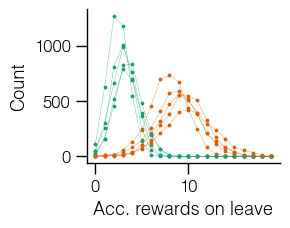

In [99]:
patch_nums = [1, 2]
colors = odor_colors[1:]
fig, axs = plt.subplots(1, 1, figsize=(2.5, 2))

print(dfs[0].columns)

all_stds = []
for df in dfs:
    stds_for_df = []
    for pn, c in zip(patch_nums, colors):
        opt_out_sites = df[(df['stopped'] == 0) & (df['patch_type'] == pn)]
        mu_zero = (opt_out_sites['rewards_seen_in_patch'] - opt_out_sites['rewards_seen_in_patch'].mean())
        std = mu_zero.std()
        stds_for_df.append(std)
        vals, bins = np.histogram(opt_out_sites['rewards_seen_in_patch'], bins=np.arange(21))
        axs.plot(bins[:-1], vals, color=c, alpha=1, lw=0.2)
        axs.scatter(bins[:-1], vals, color=c, s=3)
    all_stds.append(stds_for_df)
axs.set_xlabel('Acc. rewards on leave')
axs.set_ylabel('Count')
group_stds = np.array(all_stds)
print(group_stds)
print(group_stds.mean(axis=0))
print(group_stds.std(axis=0))
# axs.text(15, 1000, (
#     rf'Low patch $\sigma$ = {group_stds.mean(axis=0)[0]:.1f} $\pm$ {group_stds.std(axis=0)[0]:.1f}' + '\n'
#     + rf'High patch $\sigma$ = {group_stds.mean(axis=0)[1]:.1f} $\pm$ {group_stds.std(axis=0)[1]:.1f}'
# ))
format_plot(axs)
